最終課題用のノートブックのなかに、犬と猫の画像を学習したモデルを作成して、分類を行なうプログラムを作成してください。

本レッスン内容で学習した流れに沿って、深層学習プログラムを作成してください
データの前処理や水増しの処理を入れてください
MobileNetV2 のモデルを利用してください（画像サイズは MobileNetV2 が対応する大きさへのリサイズが必要です）
必ず最後に evaluate() を実行して、正答率がわかるようにしてください。

合格条件
以下の条件を満たしていれば合格となります。

全体的に見て、コードに問題がないこと
分類の正答率が0％に近いほどの悪い値でないこと

In [68]:
# 訓練データとテストデータの画像を読み込む
# （サイズは縦横224pxにリサイズする）
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
  "dog_cat_photos/train",
  image_size=(224, 224),
  label_mode="binary",
  batch_size=32,
  shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
  "dog_cat_photos/test",
  image_size=(224, 224),
  label_mode="binary",
  batch_size=32,
  shuffle=False
)


Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [69]:
# データの詳細を表示する
list(train_dataset.as_numpy_iterator())[0]


(array([[[[1.00000000e+00, 0.00000000e+00, 5.00000000e+00],
          [9.97767866e-01, 2.23214924e-03, 4.98883915e+00],
          [6.62946403e-01, 3.37053597e-01, 3.31473207e+00],
          ...,
          [7.43370514e+01, 6.26629486e+01, 3.19888458e+01],
          [7.40022278e+01, 6.29977722e+01, 3.29933167e+01],
          [7.40000000e+01, 6.30000000e+01, 3.30000000e+01]],
 
         [[1.00446427e+00, 6.69644773e-03, 5.00000000e+00],
          [1.00222218e+00, 8.91364925e-03, 4.98883915e+00],
          [6.65906012e-01, 3.41492981e-01, 3.31473207e+00],
          ...,
          [7.42730942e+01, 6.25967598e+01, 3.19360523e+01],
          [7.39352798e+01, 6.29285965e+01, 3.29375343e+01],
          [7.39330368e+01, 6.29308052e+01, 3.29441948e+01]],
 
         [[1.67410719e+00, 1.01116085e+00, 5.00000000e+00],
          [1.67037034e+00, 1.01113582e+00, 4.98883915e+00],
          [1.10984325e+00, 1.00739908e+00, 3.31473207e+00],
          ...,
          [6.46798630e+01, 5.26687050e+01, 2.4016

In [70]:
# 分類名（cat／dog）をリストとして格納する
class_names = train_dataset.class_names
class_names


['cat', 'dog']

In [74]:
# データをシャッフルする
train_dataset = train_dataset.shuffle(32)


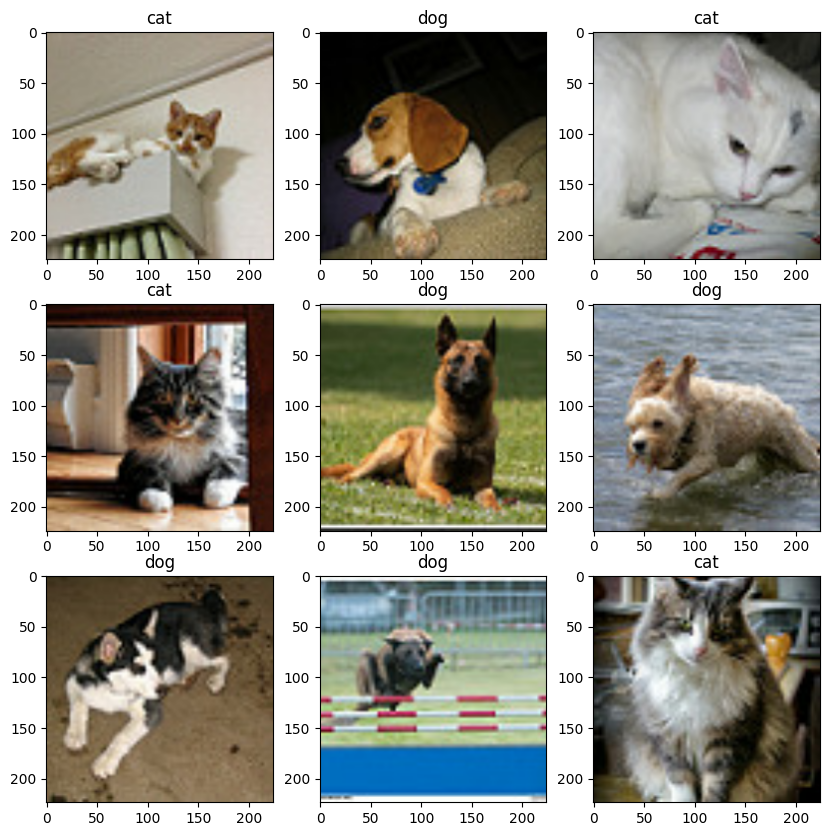

In [85]:
# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [86]:
# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
  image = tf.image.flip_left_right(image)
  return image, label

def flip_up_down(image, label):      # 上下反転
  image = tf.image.flip_up_down(image)
  return image, label

def rot90(image, label):             # 反時計回りに90度回転
  image = tf.image.rot90(image)
  return image, label

def rot180(image, label):            # 反時計回りに180度回転
  image = tf.image.rot90(image, k=2)
  return image, label

def rot270(image, label):            # 反時計回りに270度回転
  image = tf.image.rot90(image, k=3)
  return image, label


In [87]:
# 画像の水増し処理の実行
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)


In [88]:
# 水増ししたデータを訓練データに追加する
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

In [89]:
# データをシャッフルする
train_dataset = train_dataset.shuffle(32)


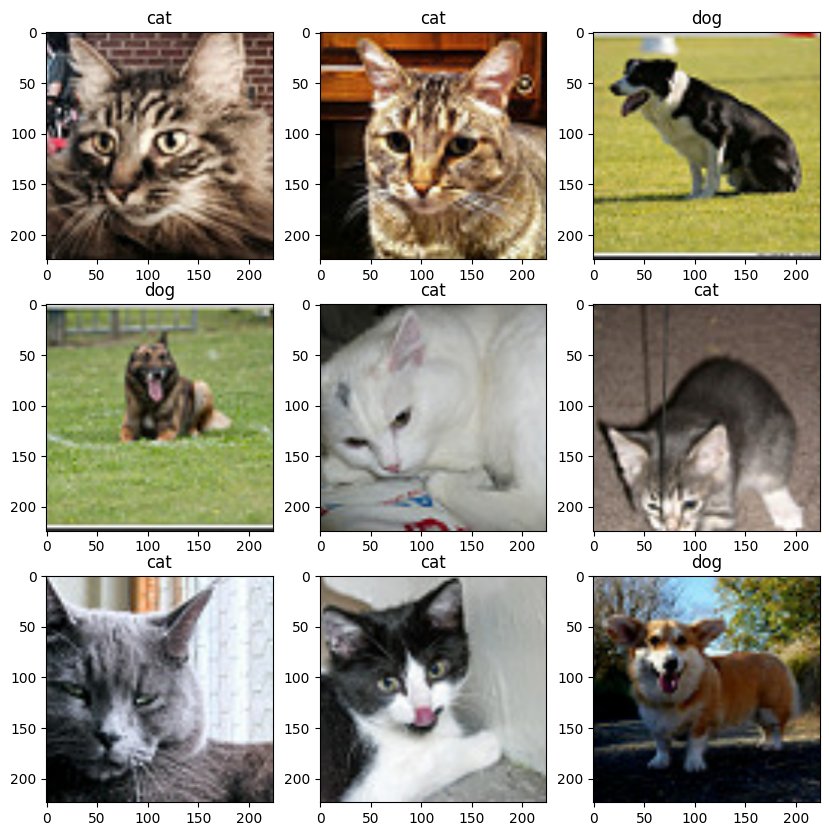

In [90]:
# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i].numpy().astype("uint8")[0]])


In [91]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層（typo直し）
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理

base_model = tf.keras.applications.MobileNetV2(
	input_shape=(224, 224, 3),
  include_top=False,
  weights=None,
  input_tensor=l_layer,
  pooling='avg'
)
base_model.trainable = False


In [92]:
# Dense層を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')


In [93]:
# base_modelに先ほどのDense層を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])


In [94]:
# modelをcompileする
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=["accuracy"])


In [95]:
# modelに学習させる
model.fit(train_dataset, epochs=20)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - accuracy: 0.4931 - loss: 0.6932
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step - accuracy: 0.5028 - loss: 0.6931
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.4868 - loss: 0.6932
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 0.4882 - loss: 0.6932
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.5100 - loss: 0.6932
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 0.4822 - loss: 0.6932
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step - accuracy: 0.4925 - loss: 0.6932
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.5083 - loss: 0.6931
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.4980 - loss: 0.6932
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 130ms/step - accuracy: 0.4982 - loss: 0.6932
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.4864 - loss: 0.6933
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/ste

In [96]:
# 分類した結果を確認する
preds = model.predict(test_dataset)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step


In [97]:
# evaluate()でモデルの性能を評価する
model.evaluate(test_dataset)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.3396 - loss: 0.6933


[0.6931473016738892, 0.5]